# The Compton Effect (Compton Scattering and Wavelength Shift)

## 0) Imports and constants

In [7]:
import numpy as np
import matplotlib.pyplot as plt

/home/jp/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### Physical constants (SI units)

We will work in SI and convert to $\AA$ (Angstrom) and keV for readability

In [8]:
h = 6.62607015e-34         # Planck constant [J-s]
c = 2.99792458e8           # speed of light [m/s]
m_e = 9.1093837015e-31     # electron rest mass [kg]
eV = 1.602176634e-19       # 1 eV in joules [J]

lambda_C = h / (m_e * c)   # electron Compton wavelength [m]

# Useful derived constants
m_e_c2 =  m_e*c**2         # electron rest energy (J)
m_e_c2_eV = m_e_c2/eV      # in eV
m_e_c2_keV = m_e_c2_eV/1e3 
m_e_c2_MeV = m_e_c2_eV/1e6 

## 1) Core Compton relations

We implement:

- $\Delta\lambda(\theta)=\lambda_C(1-\cos\theta)$

- $\lambda' = \lambda + \Delta\lambda$

- Photon energy: $E = \hbar c/\lambda$

- Energy form (useful for energy transfer plots):

$$E' = \frac{E}{1+\big(\frac{E}{m_ec^2}\big)(1-\cos\theta)}$$

In [9]:
def delta_lambda(theta_rad: np.ndarray) -> np.ndarray:
    """Compton wavelength shift: Δλ = (h/mc)(1-cosθ)."""
    return h/(m_e * c) * (1-np.cos(theta_rad))

def lambda_scattered(lambda0_m: float, theta_rad: np.ndarray) -> np.ndarray:
    """Scattered wavelength: λ' = λ + Δλ."""
    return lambda0_m + delta_lambda(theta_rad)

def scattered_wavelength(lam0, theta):
    """Alias for lambda_scattered (kept for compatibility with later cells)."""
    return lambda_scattered(lam0, theta)

def photon_energy_from_lambda(lambda_m: np.ndarray) -> np.ndarray:
    """Photon energy from wavelength: E = hc/λ."""
    return h*c/lambda_m

def photon_energy_scattered(E0_J: float, theta_rad: np.ndarray) -> np.ndarray:
    """"Scattered photon energy (energy form of Compton)."""        
    alpha = E0_J /(m_e * c**2)
    return E0_J / (1.0 + alpha * (1.0 - np.cos(theta_rad)))

def electron_kinetic_energy(E0_J: float, theta_rad: np.ndarray) -> np.ndarray:
    """Electron kinetic energy: K = E - E'."""
    Eprime = photon_energy_scattered(E0_J, theta_rad)
    return E0_J- Eprime

def photon_energy_from_lambda(lam):
    """Photon energy (J) from wavelength (m): E = hc/λ."""
    return h*c/lam

def scattered_photon_energy(E0, theta):
    """Scattered photon energy (J) from incident photon energy E0 (J) and scattering angle θ (rad).

    Relativistic Compton formula in energy form:
        E' = E0 / [1 + (E0/(m_e c^2)) (1 - cosθ)].
    """
    return E0 / (1.0 + (E0/m_e_c2)*(1.0 - np.cos(theta)))

def alpha_from_energy(E0):
    """Dimensionless parameter α = E0/(m_e c^2). α measures how 'relativistic' the recoil can be."""
    return E0/m_e_c2

def recoil_momentum_magnitude(E0, theta):
    """Magnitude of the recoil-electron momentum (kg⋅m/s) using photon momenta and the scattering angle.

    Using vector substraction: p_e = p_γ - p_γ'
    with p_γ = E0/c and p_γ' = E'(θ)/c.
    """
    Ep = scattered_photon_energy(E0, theta)
    p = E0/c
    pp = Ep/c
    return np.sqrt(p**2 + pp**2 - 2*p*pp*np.cos(theta))

def recoil_angle_phi(E0, theta):
    """Electron recoil angle ϕ (rad) relative to the incident photon direction.

    Components from momentum conservation (choose x along the incident photon):
        p_ex = p_γ - p_γ' cosθ
        p_ey = p_γ' sinθ
    so  tanϕ = p_ey / p_ex.
    """
    Ep = scattered_photon_energy(E0, theta) 
    p = E0/c
    pp = Ep/c
    p_ex = p - pp * np.cos(theta)
    p_ey = pp * np.sin(theta)
    phi = np.arctan2(p_ey, p_ex)
    return phi

def recoil_angle_phi_closed_form(E0, theta):
    """Same ϕ but using the compact relation: cotϕ = (1 + α) tan(θ/2)."""
    a = alpha_from_energy(E0)
    # cotφ = (1 + α) tan(θ/2) -> φ = arctan[1 / ((1+α) tan(θ/2))]
    return np.arctan2(1.0, (1.0 + a)*np.tan(theta/2.0))

## 2) Classical expecttation vs quantum picture (conceptual baseline)

Here we include a simple "classical baseline" curve for discussion:

- In a  wave-only picture, energy transfer is typically thought of as continuous, so one expects a spread in outcomes rather than a **single shifted line**.

- As a minimal baseline, we represent "no discrete shift" as (\lambda'\approx\lambda).

  **Didactic note:** This is not meant to be a full classical scattering theory; it is a *contrast* tool. 

In [10]:
def classical_no_shift(lambda0_m: float, theta_rad: np.ndarray) -> np.ndarray:
    """Minimal classical baseline: no discrete wavelength shift (λ' = λ)."""
    return np.full_like(theta_rad, lambda0_m, dtype=float)

## 3) Verification: the straight-line test (lab-style)

From theory:

$$\Delta\lambda=\lambda_C(1-\cos\theta)$$

So a plot of $\Delta\lambda$ vs $(1-\cos\theta)$ should be a straight line whose slope estimates $\lambda_C=\hbar/(m_ec)$.

In [11]:
def linear_fit_compton(theta_rad: np.ndarray, dlam_m: np.ndarray):
    """Fit Δλ vs (1- cosθ) + intercept."""
    x = 1.0 - np.cos(theta_rad)
    y = dlam_m
    slope, intercept = np.polyfit(x, y, deg=1)
    return slope, intercept

## 4) Choose an incident wavelength (X-ray scale)

Typical Compton experiments use X-rays. You can enter:

- wavelength in $\AA$ (Angstrom), e.g. 0.71 $\AA$

- or define energy and convert, if you prefer

We'll compute:

- $\Delta\lambda(\theta)$

- $\lambda'(\theta)$

- $E'(\theta)$ and electron kinetic energy ($K(\theta)$)

In [12]:
lambda0_A = 0.71    # incident wavelength in Å (change if desired)
lambda0_m = lambda0_A * 1e-10

theta_deg = np.linspace(0, 180, 361)
theta_rad = np.deg2rad(theta_deg)

dlam = delta_lambda(theta_rad)
lam_prime = lambda_scattered(lambda0_m, theta_rad)

E0 = photon_energy_from_lambda(np.array([lambda0_m]))[0]
Eprime = photon_energy_scattered(E0, theta_rad)
K = electron_kinetic_energy(E0, theta_rad)

lam_classical = classical_no_shift(lambda0_m, theta_rad)

slope, intercept = linear_fit_compton(theta_rad, dlam)

print("--- Input photon ---")
print(f"lambda0 = {lambda0_A:.4f} Angstrom")
print(f"E0 = {E0/eV/1e3:.3f} keV")
print("\n--- ELlectron Compton wavelength ---")
print(f"lambda_C = h/(m_e c) = {lambda_C*1e12:.4f} pm = {lambda_C*1e10:.4f} Angstrom")
print("\n--- Verification fit: Delta lambda vs (1-cos theta) ---")
print(f"slope     = {slope*1e12:.4f} pm (expected {lambda_C*1e12:.4f} pm)")
print(f"intercept = {intercept:.2e} m (should be ~0)")

--- Input photon ---
lambda0 = 0.7100 Angstrom
E0 = 17.463 keV

--- ELlectron Compton wavelength ---
lambda_C = h/(m_e c) = 2.4263 pm = 0.0243 Angstrom

--- Verification fit: Delta lambda vs (1-cos theta) ---
slope     = 2.4263 pm (expected 2.4263 pm)
intercept = 2.53e-28 m (should be ~0)


## 5) Plot 1 — Key observation: $\Delta\lambda$ depends only on $\theta$

**Didactic point:** The shift is a purely kinematic effect and increases with scattering angle.

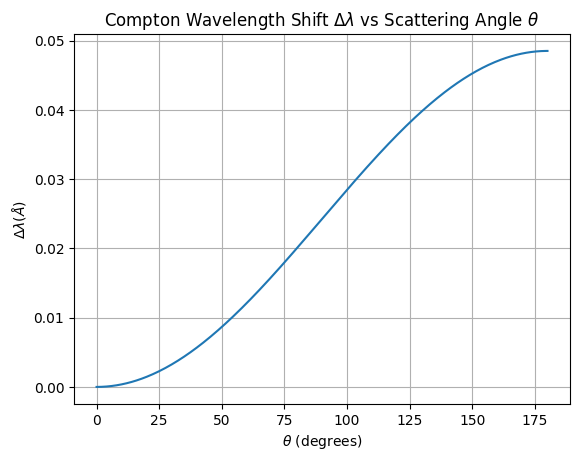

In [13]:
plt.figure()
plt.title("Compton Wavelength Shift $\Delta\lambda$ vs Scattering Angle $\\theta$")
plt.xlabel("$\\theta$ (degrees)")
plt.ylabel("$\Delta\lambda (\AA)$")
plt.plot(theta_deg, dlam * 1e10)
plt.grid(True)
plt.show()

## 6) Plot 2 — Classical baseline vs quantum prediction

**Classical (wave-only intuition):** no single discrete shifted line is expected (baseline shown as no shift).
**Quantum (photon collision):** predicts a definite $\lambda'(\theta)$ with a specific angular dependence.

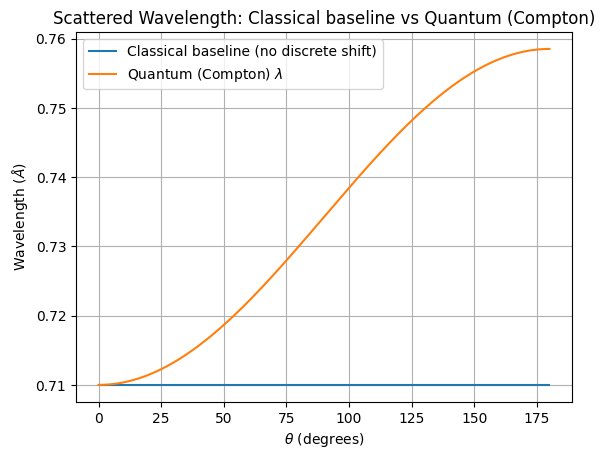

In [14]:
plt.figure()
plt.title("Scattered Wavelength: Classical baseline vs Quantum (Compton)")
plt.xlabel("$\\theta$ (degrees)")
plt.ylabel("Wavelength $(\AA)$")
plt.plot(theta_deg, lam_classical * 1e10, label="Classical baseline (no discrete shift)")
plt.plot(theta_deg, lam_prime * 1e10, label="Quantum (Compton) $\lambda$")
plt.legend()
plt.grid(True)
plt.show()

## 7) Plot 3 — Energy transfer (photon loses energy, electron gains kinetic energy)

In the photon-electron collision picture:

- The scattered photon has lower energy $E'(\theta)$.

- The difference $K(\theta) = E - E'$ appears as the electron's kinetic energy.

**Didactic sentence (slide-style):**
Energy transferred to the electron appears as a loss in the photon's energy.

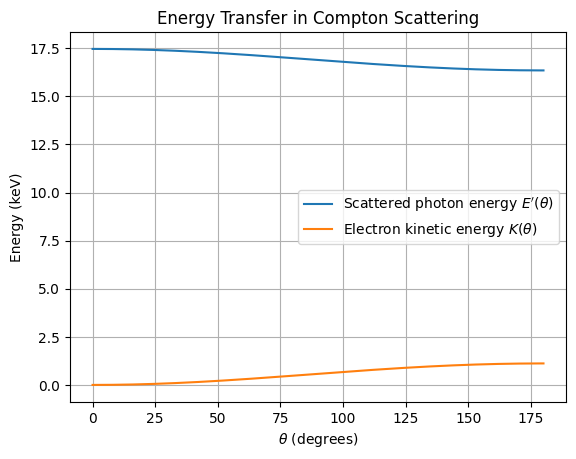

In [15]:
plt.figure()
plt.title("Energy Transfer in Compton Scattering")
plt.xlabel("$\\theta$ (degrees)")
plt.ylabel("Energy (keV)")
plt.plot(theta_deg, Eprime / (1e3 * eV), label="Scattered photon energy $E'(\\theta)$")
plt.plot(theta_deg, K / (1e3 * eV), label="Electron kinetic energy $K(\\theta)$")
plt.legend()
plt.grid(True)
plt.show()

## 8) Plot 4 — Verification: straight-line test of the Compton law

**What Plot 4 shows:** a linear verification plot using the Compton prediction

$$\Delta\lambda = \lambda_C(1-\cos\theta).$$

**Step A — Build the two arrays**

For each scattering angle $(\theta)$, compute:

- **x-axis:** $x = 1 - \cos\theta$ (dimensionless)

- **y-axis:** $y = \Delta\lambda = \lambda' - \lambda_0$ (in meters or $\AA$)

**Step B — Plot and fit a straight line**

Make **Plot 4** as:

$$y \,\ \text{vs} \,\ x,$$

and fit $y = ax + b$.

- The **slope** should be $a \approx \lambda_C = \frac{\hbar}{m_e c}$.

- The **intercept** should be $b \approx 0$.

**What you should observe (quick check)**

- The points lie close to a straight line.

- The fitted slope is close to $\lambda_C\approx 2.426\times 10^{-12}m$ (or $0.02426 \AA$).

- The intercept is near zero (small numerical/fit error is normal)

**Didactic point:** this plot mimics an experimental verification: it tests the *angle dependence* and extracts $\lambda_C$ from the slope.
**Note:** In this notebook, the actual figure for this verification appears later as the plot titled
**"Straight-Line Test: $\Delta\lambda$ vs $(1-\cos\theta)$".**
It is currently generated inside the section **"11) Quick practice problems (for students)"** (look for the code that defines $\texttt{x = 1.0 - np.cos(theta\_rad)}$ and then plots $\texttt{Δλ}$ vs $\texttt{x}$). So, even though the verification is explained here, the corresponding plot is displayed further down in the notebook.

## 9) The angles $\theta$ and $\phi$ (what sets them?)

In the standard Compton-scattering setup:

- We **choose** the incident photon to travel along the $x-$axis.

- The detector is palced at some direction, so it **selects the scattered photon angle $\theta$**.

- Once **$\theta$** (and the incident energy) are fixed, the electron cannot recoil arbitrarily: **energy + momentum conservation determine the electron recoil angle $\phi$** and its kinetic energy.

A useful way to see this is to write the momentum conservation in components:

$$\vec{p}_{\gamma} = \vec{p}_{\gamma'} + \vec{p}_{e}.$$

Choosing $x$ along the incident photon:

$$p_e\cos\phi = p_{\gamma} - p_{\gamma'}\cos\theta,$$

$$p_e\sin\phi = p_{\gamma'}\sin\theta.$$

So the **photon angle $\theta$ is set by your detector geometry**, while **$\phi$ is a consequence** of those two equations (after you use the Compton energy relation to connect $p_{\gamma}$ and $p_{\gamma'}$).

We often introduce the dimensionless parameter

$$\alpha \equiv \frac{\hbar\nu}{m_ec^2}=\frac{E_{\gamma}}{m_ec^2},$$

which measures "how relativistic" the interaction is: if $\alpha \ll 1$ the recoil is small, while $\alpha\gtrsim 1$ means the photon energy is comparable to the electron rest energy (511 keV), so relativistic kinematics is essential.

For a single incident photon, the scattering angle $\theta$ is not predetermined by the incoming photon. The photon enters along a fixed direction (this defines the reference axis), but after the interaction it leaves in one specific direction, so that event has a definite $\theta$. In quantum terms, $\theta$ is an outcome of the scattering process (random from event to event, with an angle-dependent probability), not a value the photon "chooses" in advance. A detector placed at some direction does not force the photon to scatter there; it simply answers: did the photon emerge within this angular range—yes or no?

The probability that a single photon scatters into a given direction depends on the angular scattering distribution, i.e., the differential cross section $\frac{d\sigma}{d\Omega}$​. For Compton scattering from a free electron at rest, this distribution is given by the Klein–Nishina formula, so it depends mainly on the scattering angle $\theta$ and on the incident photon energy through $\alpha=\frac{E_{\gamma}}{(m_e c^2)}$​​ (which sets how relativistic the recoil is). In real materials, the observed probability can also be affected by electron binding and by experimental factors such as the detector’s solid-angle acceptance $\Delta\Omega$ and efficiency.

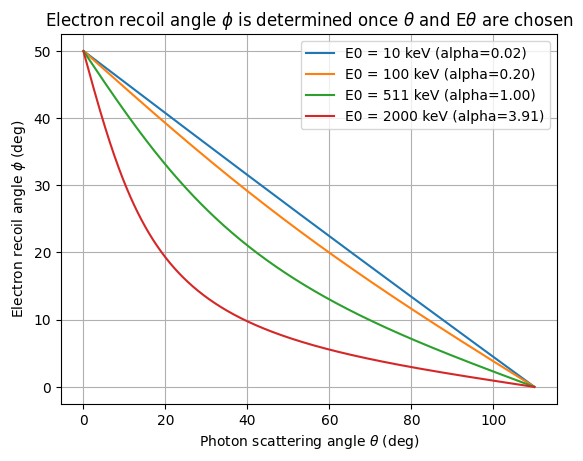

max |Delta phi| (deg) = 4.274665491886967e-12


In [16]:
# Explore how φ depends on ϑ and on the incident photon energy.

thetas = np.linspace(1e-3, np.pi-1e-3, 600)

# Pick a few incident photon energies (in keV) to illustrate the role of α = E/(m_ec^2)
E0_list_keV = [10, 100, 511, 2000]   # 10 keV (soft X-ray), 100 keV, 511 keV, 2 MeV
E0_list = [E*1e3*eV for E in E0_list_keV]  # convert keV -> J

plt.figure()
for E0, E0_keV in zip(E0_list, E0_list_keV):
    phi = recoil_angle_phi(E0, thetas)
    plt.plot(thetas*110/np.pi, phi*100/np.pi, label=f"E0 = {E0_keV} keV (alpha={alpha_from_energy(E0):.2f})")
plt.xlabel("Photon scattering angle $\\theta$ (deg)")
plt.ylabel("Electron recoil angle $\phi$ (deg)")
plt.title("Electron recoil angle $\phi$ is determined once $\\theta$ and E$\\theta$ are chosen")
plt.legend()
plt.grid(True)
plt.show()    

# Quick check: numerical φ vs closed-form φ (they should match)

E0_test = 511e3*eV
phi_num = recoil_angle_phi(E0_test, thetas)
phi_cf = recoil_angle_phi_closed_form(E0_test, thetas)
print("max |Delta phi| (deg) =", np.max(np.abs(phi_num-phi_cf))*180/np.pi)

## 12) Virtual Experiment 1 — How $\theta$ is chosen in the lab (goniometer scan + angular acceptance)

In a real Compton-scattering experiment, **$\theta$ is not predicted by the theory**—it is **selected by the apparatus:**

- The **detector** is mounted on a **rotating arm (goniometer)** centered at the scattering target.

- Setting the arm at a central angle **$\theta_0$** defines the nominal photon scattering angle.

- Because the detector and collimators have a finite size, the setup actually accepts a **range of angles** around $\theta_0$. A simple geometric estimate for the **half-acceptance angle** is

$$\delta\theta\approx\arctan\big(\frac{D/2}{R}\big),$$

where

- $D$ is the effective aperture (collimator diameter or detector active width),

- $R$ is the target-detector distance.

**What you will simulate:** a goniometer scan in $\theta_0$ and the resulting broadening of the measured $\lambda'$ distribution due to finite angular acceptance.

Geometry:
 R = 0.100 m, D = 0.050 m
 half-acceptance delta theta = 14.036 deg


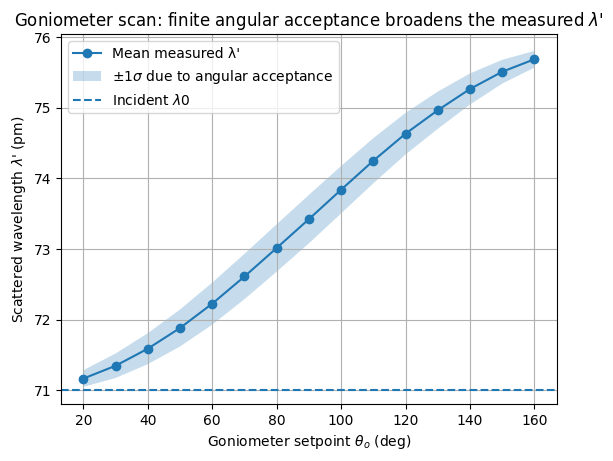

In [17]:
# Virtual Experiment 1: goniometer scan with finite angular acceptance

# --- Geometry knobs (edit these) ---
R = 0.10      # target-to-detector distance [m]
D = 0.05      # effective aperture diameter [m] (collimator/detector width)

# Half-acceptance angle (rad)
dtheta = np.arctan((D/2)/R)

print(f"Geometry:")
print(f" R = {R:.3f} m, D = {D:.3f} m")
print(f" half-acceptance delta theta = {np.rad2deg(dtheta):.3f} deg")

# --- Scan settings ---
theta0_deg = np.arange(20, 161, 10)          # goniometer setpoints (deg)
N = 5000                                     # samples per setpoint (simulated counts)

theta0 = np.deg2rad(theta0_deg)

# Sample accepted angles around each ϑ0 (uniform acceptance model)
rng = np.random.default_rng(7)
theta_samples = theta0[:, None] + rng.uniform(-dtheta, dtheta, size=(len(theta0), N))

# Compute scattered wavelengths for each sampled angle
lam_samples = lambda0_m + lambda_C * (1 - np.cos(theta_samples))

# Summary statistics (for visualization)
lam_mean = lam_samples.mean(axis=1)
lam_std = lam_samples.std(axis=1)

# Convert to picometers (pm) for display purposes
pm = 1e12
lam0_pm = lambda0_m * pm
lam_mean_pm = lam_mean * pm
lam_std_pm = lam_std * pm

# Plot: measured λ' vs θ0
plt.figure()
plt.plot(theta0_deg, lam_mean_pm, marker='o', label="Mean measured λ'")
plt.fill_between(theta0_deg, lam_mean_pm - lam_std_pm, lam_mean_pm + lam_std_pm, alpha=0.25,
                 label="$\pm 1\sigma$ due to angular acceptance")
plt.axhline(lam0_pm, linestyle='--', label="Incident $\lambda 0$")
plt.xlabel("Goniometer setpoint $\\theta_o$ (deg)")
plt.ylabel("Scattered wavelength $\lambda$' (pm)")
plt.title("Goniometer scan: finite angular acceptance broadens the measured $\lambda$'")
plt.grid(True)
plt.legend()
plt.show()

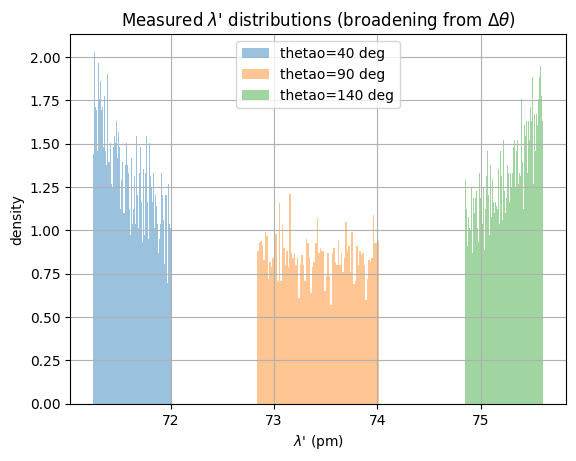


Key takeaway:
 theta varies because the detector is *moved* (goniometer), and each setting thetao
 actually corresponds toa  finite acceptance angular range ~ [thetao - delta theta, thetao + delta theta].
 Larger D or smaller R -> larger delta theta -> broader measured peak in lambda' (or E).


In [18]:
# Visualize the wavelength distribution at a couple of angles (histograms)
angles_to_show = [40, 90, 140]  # deg (must be in theta0_deg list)
plt.figure()
for ang in angles_to_show:
    i = np.where(theta0_deg == ang)[0][0]
    plt.hist(lam_samples[i] * pm, bins=80, alpha=0.45, density=True, label=f"thetao={ang} deg")
plt.xlabel("$\lambda$' (pm)")
plt.ylabel("density")
plt.title("Measured $\lambda$' distributions (broadening from $\Delta\\theta$)")
plt.grid(True)
plt.legend()
plt.show()

# Key takeaway (printed)
print(f"\nKey takeaway:")
print(f" theta varies because the detector is *moved* (goniometer), and each setting thetao")
print(f" actually corresponds toa  finite acceptance angular range ~ [thetao - delta theta, thetao + delta theta].")
print(f" Larger D or smaller R -> larger delta theta -> broader measured peak in lambda' (or E).")

## 13) Virtual Experiment 2 — WHen does relativity matter? (Relativistic vs non-relativistic recoil)

The **Compton shift** formula already comes from **energy-momentum conservation** with relativistic kinematics. However, when we compute the **recoiling electron kinetic energy $K$**, we have two options:

- **Relativistic correct:** 

$$K_{\text{rel}} = \sqrt{(p_ec)^2 + (m_ec^2)^2} - m_e c^2$$

- **Non-relativistic approximation (only valid at low speed):**

$$K_{\text{NR}} \approx \frac{p_e^2}{2m_e}$$

A convenient parameter is

$$\alpha = \frac{E_0}{m_ec^2}.$$

- If $\alpha \ll 1$, recoil is weak and $K_{\text{NR}}$ can be accurate.

- If $\alpha \gtrsim 0.1$, recoil becomes significant and **relativistic dynamics is required**.

**What you will simulate:** compare $K_{\text{NR}}$ and $K_{\text{rel}}$ across photon energies and identify when the non-relativistic approximation breaks down. 

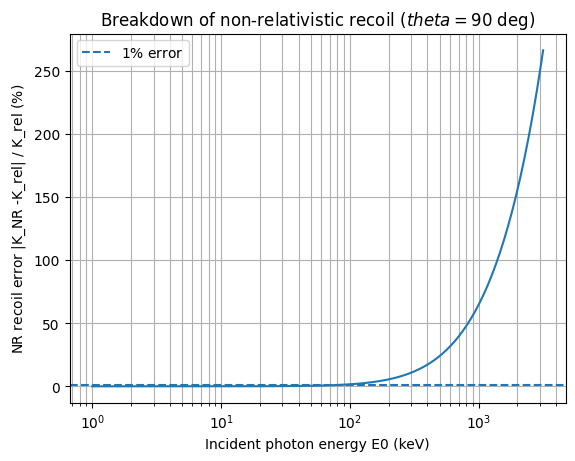

In [15]:
# Virtual Experiment 2: Relativistic vs non-relativistic electron recoil

# Choose a representative scattering angle
theta_test_deg = 90
theta_test = np.deg2rad(theta_test_deg)

# Energy scan
E0_keV = np.logspace(0, 3.5, 220)   # 1 keV ... ~3162 keV
E0 = E0_keV * 1e3 * eV              # J   

# Scattered photon energy (exact Compton)
Eprime = scattered_photon_energy(E0, theta_test)

# Electron recoil momentum magnitude from momentum conservation 
pe = recoil_momentum_magnitude(E0, theta_test)

# Kinetic energies
K_rel = np.sqrt((pe*c)**2 + (m_e_c2)**2) - m_e_c2     # J
K_NR = pe**2 / (2*m_e)                                  # J  

# Electron speed (from relativistic relations): beta = pc / E_total
E_total = K_rel + m_e_c2
beta = (pe*c) / E_total

# Percent error of NR vs relativistic
err_pct = np.abs(K_NR - K_rel) / np.maximum(K_rel, 1e-30) * 100

# Plot error vs energy
plt.figure()
plt.semilogx(E0_keV, err_pct)
plt.axhline(1.0, linestyle='--', label="1$\%$ error")
plt.xlabel("Incident photon energy E0 (keV)")
plt.ylabel("NR recoil error |K_NR -K_rel| / K_rel ($\%$)")
plt.title(f"Breakdown of non-relativistic recoil ($theta = {theta_test_deg}$ deg)")
plt.grid(True, which="both")
plt.legend()
plt.show()

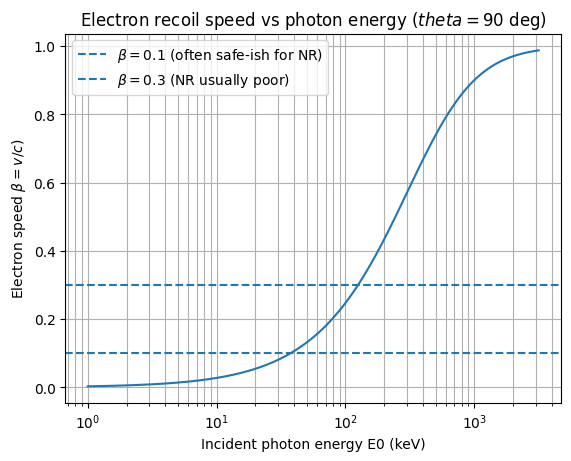

In [16]:
# Plot beta vs energy (how relativistic the electron gets)
plt.figure()
plt.semilogx(E0_keV, beta)
plt.axhline(0.1, linestyle='--', label="$\\beta=0.1$ (often safe-ish for NR)")
plt.axhline(0.3, linestyle='--', label="$\\beta=0.3$ (NR usually poor)")
plt.xlabel("Incident photon energy E0 (keV)")
plt.ylabel("Electron speed $\\beta=v/c$)")
plt.title(f"Electron recoil speed vs photon energy ($theta = {theta_test_deg}$ deg)")
plt.grid(True, which="both")
plt.legend()
plt.show()

In [17]:
# Identify energy thresholds
# (1) energy where NR error first exceeds 1%
idx1 = np.argmax(err_pct > 1.0)
E_threshold_1pct = E0_keV[idx1] if np.any(err_pct > 1.0) else None

# (2) energy where beta exceeds 0.1
idxb = np.argmax(beta > 0.1)
E_threshold_beta = E0_keV[idxb] if np.any(beta > 0.1) else None
print(f"At theta = {theta_test_deg} deg:")
if E_threshold_1pct is not None:
    print(f" NR recoil error exceeds 1% at about E0 >~ {E_threshold_1pct:.1f} keV")
else:
    print(" NR recoil error stays below $1\%$ over this energy range.")    
if E_threshold_beta is not None:
    print(f" Electron speed exceeds beta=0.1 at about E0 >~ {E_threshold_beta:.1f} keV")    
else:
    print(" Electron speed stays below beta=0.1 over this energy range.") 

print("\n Interpretation:")
print(" - If the recoil electron stays slow (beta ~< 0.1), K ~= p^2/(2m) is often acceptable")
print(" - Once beta grows, the NR kinetic-energy formula underetimates K and the error rises quickly.")
print(" - The Compton wavelength shift itself comes from relativistic conservation laws—")
print(" - the NR approximation is only about *how you compute the electron recoil energy*.")

At theta = 90 deg:
 NR recoil error exceeds 1% at about E0 >~ 79.8 keV
 Electron speed exceeds beta=0.1 at about E0 >~ 38.2 keV

 Interpretation:
 - If the recoil electron stays slow (beta ~< 0.1), K ~= p^2/(2m) is often acceptable
 - Once beta grows, the NR kinetic-energy formula underetimates K and the error rises quickly.
 - The Compton wavelength shift itself comes from relativistic conservation laws—
 - the NR approximation is only about *how you compute the electron recoil energy*.


## 10) Interpreting the measured spectrum: unshifted vs Compton-shifted peaks

Compton's key observation was that the scattered X-ray spectrum typically contains:

- an **unshifted** line (same $\lambda_0$ as the incident beam), and
- a **shifted** line at $\lambda'=\lambda_0 + \Delta\lambda(\theta)$.

The shifted line is explained by **photon–electron collisions** (free or weakly bound electrons), giving the Compton shift

$$\Delta\lambda = \lambda' - \lambda_0= \lambda_C(1-\cos\theta).$$

The unshifted line is commonly attributed to scattering from the **atom as a whole** (or tightly bound electrons). If the effective scattering mass is the atom's mass $M≫m_e$, then the shift

$$\Delta\lambda = \frac{\hbar}{Mc}(1-\cos\theta)$$

is so tiny that it is experimentally indistinguishable from **zero**—so it appears as an "unmodified" peak.

The simple simulation below draws two Gaussian peaks to visualize how the spectrum looks as $\theta$ changes.


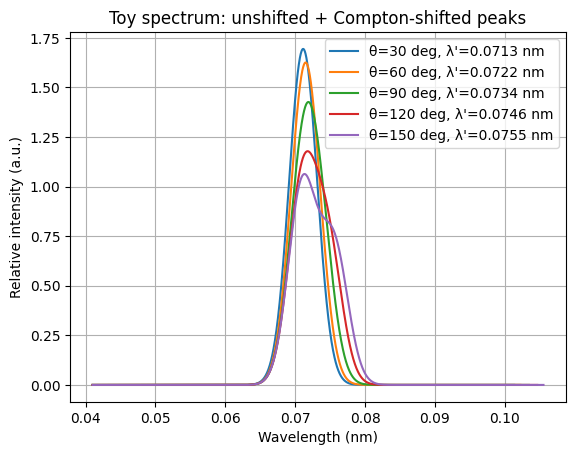

Incident photon energy ≈ 17.462563159605672 keV


In [18]:
def two_peak_spectrum(lam0, theta, sigma=0.002e-9, A0=1.0, A1=0.7, n=2000, span=0.03e-9):
    """Toy model: unshifted + Compton-shifted Gaussian peaks.
    lam0: incident wavelength (m)
    theta: scattering angle (rad)
    sigma: peak width (m)
    span: half-width of plotting window (m)
    """

    lam1 = scattered_wavelength(lam0, theta)

    lam_min = lam0 - span
    lam_max = lam1 + span

    lam_array = np.linspace(lam_min, lam_max, n)

    peak_unshifted = A0 * np.exp(-(lam_array - lam0)**2 / (2 * sigma**2))
    peak_shifted = A1 * np.exp(-(lam_array - lam1)**2 / (2 * sigma**2))
    I = peak_unshifted + peak_shifted

    return lam_array, I, lam1

lam0 = 0.071e-9     # ~17.5 keV X-ray (typical Compton experiments); feel free to change
theta_list_deg = [30, 60, 90, 120, 150]

plt.figure()
for th_deg in theta_list_deg:
    th = np.deg2rad(th_deg)
    lam, I, lam1 = two_peak_spectrum(lam0, th)
    plt.plot(lam*1e9, I, label=f"θ={th_deg} deg, λ'={lam1*1e9:.4f} nm")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Relative intensity (a.u.)")
plt.title("Toy spectrum: unshifted + Compton-shifted peaks")
plt.legend()
plt.grid(True)
plt.show()

print("Incident photon energy ≈", photon_energy_from_lambda(lam0)/eV/1e3, "keV")

## 11) Quick practice problems

Try changing the numbers and re-runnig the cell. Suggested prompts:

1. **Given** $\lambda_0$ and $\theta$, compute $\lambda', E'$, and the electron kinetic energy $K_e$

2. For a **fixed** $\lambda_0$, compare $\theta=0\degree$ and $\theta=180\degree$. What is the maximum possible shift?

3. For **high-energy photons** (e.g., $E_0\sim 1$MeV), evaluate $\alpha$. Is the recoil strongly relativistic?

In [19]:
# Example calculation (edit values)

theta_deg = 120
theta = np.deg2rad(theta_deg)

# Choose ONE of the two ways to specify the incident photon:
lam0 = 0.071e-9           # meters (comment this line out if you want to use E0 directly)
E0 = photon_energy_from_lambda(lam0)     # Joules

# Alternatively:
# E0 = 0.9e6*eV           # 0.9 MeV
# lam0 = h*c/E0

lam_p = scattered_wavelength(lam0, theta)
E_p   = scattered_photon_energy(E0, theta)
K_e   = (E0 - E_p)        # electron kinetic energy from energy conservation
phi   = recoil_angle_phi(E0, theta)

print(f"θ  = {theta_deg:.1f}°")
print(f"λ0 = {lam0*1e12:.3f} pm")
print(f"λ' = {lam_p*1e12:.3f} pm")
print(f"Δλ = {(lam_p-lam0)*1e12:.3f} pm")

print(f"E0  = {E0/eV/1e3:.3f} keV")
print(f"E'  = {E_p/eV/1e3:.3f} keV")
print(f"K_e = {K_e/eV/1e3:.3f} keV")
print(f"α   = {alpha_from_energy(E0):.3f}")

print(f"φ   = {phi*180/np.pi:.2f}°  (electron recoil angle)")

θ  = 120.0°
λ0 = 71.000 pm
λ' = 74.639 pm
Δλ = 3.639 pm
E0  = 17.463 keV
E'  = 16.611 keV
K_e = 0.851 keV
α   = 0.034
φ   = 29.17°  (electron recoil angle)


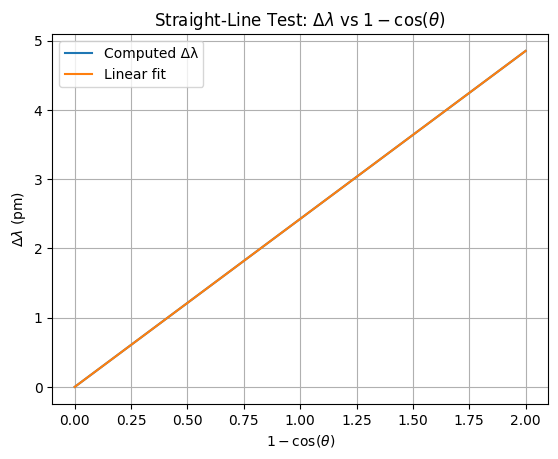

In [20]:
theta_deg = np.linspace(0, 180, 181)
theta = np.deg2rad(theta_deg)
delta_lambda = lambda_C * (1 - np.cos(theta))
x = 1 - np.cos(theta)
m, b = np.polyfit(x, delta_lambda, 1)
plt.figure()
plt.plot(x, delta_lambda * 1e12, label="Computed Δλ")
plt.plot(x, (m * x + b) * 1e12, label="Linear fit")
plt.xlabel("$1 - \cos(\\theta)$")
plt.ylabel("$\Delta\lambda$ (pm)")
plt.title("Straight-Line Test: $\Delta\lambda$ vs $1 - \cos(\\theta)$")
plt.grid(True)
plt.legend()
plt.show()

### Optional extnsion A — Connect to the lecture's main formula

The central result of the Compton effect is:

$$\Delta\lambda = \lambda' - \lambda = \frac{h}{m_ec}(1-\cos\theta)$$

It predicts:

- zero shift at $\theta =0\degree$

- maximum shift at $\theta = 180\degree$

- deèndence only on $\thete$ and the electron mass

In experiments, a low Z-target (e.g., graphite) helps because outer electrons are weakly bound and can be approximated as "free".

### Optional extension B — "Low Z-target" note (slide-ready)

**Low Z-material:** a target made of low atomic-number elements (small Z), so outer electrons are weakly bound and can be treated approximately as free in Compton scattering.

## 14) Add-on — Real non-relativistic recoil regime (soft X-rays / small angles)

This short add-on answers a common question:

> **When is the electron recoil truly non-relativistic in a real Compton/scattering setting?**

A practical condition is **small recoil speed**:

$$
\beta = \frac{\nu}{c} \ll 1
\qquad \Longleftrightarrow \qquad
K \ll m_e c^2 \approx 511\ \text{keV}.
$$

In many **soft X-ray** experiments ($E_0 \sim 5$-$20$ keV), the dimensionless parameter

$$
\alpha = \frac{E_0}{m_e c^2}
$$

is typically $\alpha \sim 0.01$--$0.04$. Even for **backscattering**
($\theta = 180^\circ$), the electron recoil kinetic energy is only a few
$10^2$ eV to $\sim 1$ keV, so $\beta$ stays small and the
non-relativistic approximation $K_{\text{NR}} \approx \frac{p^2}{2m_e}$ becomes very accurate.

**What you will compute here:**

- For several soft X-ray energies, compute $K_{\rm rel}$, $\beta$, and the NR error at $\theta = 180^\circ$.

- For a fixed soft X-ray energy, scan $\theta$ and confirm $\beta$ remains small for all angles (NR regime).

,E0 (keV),alpha=E0/(mec^2),K_rel (keV),beta=v/c,NR error (%)
0,5.0,0.009785,0.095969,0.019378,0.009390
1,8.0,0.015656,0.242885,0.030821,0.023766
2,10.0,0.019570,0.376649,0.038374,0.036854
3,17.4,0.034051,1.109420,0.065788,0.108554
4,20.0,0.039139,1.451908,0.075223,0.142066


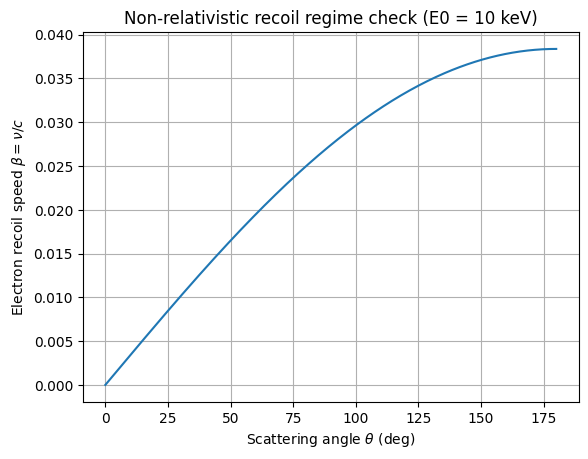

Max beta over all angles (E0=10 keV): 0.03837365622374385
Rule of thumb: beta << 1 (e.g., beta < 0.1) implies a solid non-relativistic recoil regime.


In [31]:
# Add-on: demonstrate a real non-relativistic recoil case
# This cell assumes you have already implemented:
#   scattered_photon_energy(E0, theta)
#   recoil_momentum_magnitude(E0, theta)
# in the earlier TODO sections.

# --- Part A: Backscattering (theta = 180∘) at soft X-ray energies ---
theta_bs = np.deg2rad(180)

E0_keV_list = [5, 8, 10, 17.4, 20]  # typical soft X-ray energies
E0_list = np.array(E0_keV_list) * 1e3 * eV  # keV -> 3

rows = []
for E0_keV, E0 in zip(E0_keV_list, E0_list):
    alpha = E0 / m_e_c2

    Eprime = scattered_photon_energy(E0, theta_bs)
    pe = recoil_momentum_magnitude(E0, theta_bs)

    # Relativistic kinetic energy (from momentum)
    K_rel = np.sqrt((pe*c)**2 + (m_e_c2)**2) - m_e_c2

    # Non-relativistic estimate
    K_NR = pe**2 / (2*m_e)

    # beta = (p c) / E_total, where E_total = K_rel + m_e c^2
    E_total = K_rel + m_e_c2
    beta = (pe*c) / E_total

    err_pct = abs(K_NR - K_rel) / K_rel * 100

    rows.append((E0_keV, float(alpha), K_rel/eV/1e3, beta, err_pct))

#import pandas as pd
# Display a compact table 
if 'pd' in globals() and pd is not None:
    df = pd.DataFrame(rows, columns=["E0 (keV)", "alpha=E0/(mec^2)", "K_rel (keV)", "beta=v/c", "NR error (%)"])
    display(df)
else:
    headers = ["E0(keV)", "alpha", "K_rel(keV)", "beta", "NR_error(%)"]

    print(
        f"{headers[0]:>8} "
        f"{headers[1]:>10} "
        f"{headers[2]:>12} "
        f"{headers[3]:>10} "
        f"{headers[4]:>14}"
    )

    for E0_keV, alpha, K_rel_keV, beta, err_pct in rows:
        print(
            f"{E0_keV:8.1f} "
            f"{alpha:10.5f} "
            f"{K_rel_keV:12.6f} "
            f"{beta:10.5f} "
            f"{err_pct:14.4f}"
        ) 
# --- Part B: Angle scan at a fixed soft X-ray energy ---
E0_keV = 10.0
E0 = E0_keV * 1e3 * eV

theta_deg = np.linspace(0, 180, 361)
theta = np.deg2rad(theta_deg)

E_prime = scattered_photon_energy(E0, theta)
pe = recoil_momentum_magnitude(E0, theta)

K_rel = np.sqrt((pe*c)**2 + (m_e_c2)**2) - m_e_c2
E_total = K_rel + m_e_c2
beta = (pe*c) / E_total

plt.figure()
plt.plot(theta_deg, beta)
plt.xlabel("Scattering angle $\\theta$ (deg)")
plt.ylabel("Electron recoil speed $\\beta=\\nu/c$")
plt.title("Non-relativistic recoil regime check (E0 = 10 keV)")
plt.grid(True)
plt.show()

print("Max beta over all angles (E0=10 keV):", max(beta))
print("Rule of thumb: beta << 1 (e.g., beta < 0.1) implies a solid non-relativistic recoil regime.")